[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss compliance optimization

Last updated: 06/27/26

## Description

Optimize the compliance of a truss structure to achieve its 
maximum stiffness with a given amount of material. 

Objective function: compliance of the structure, expressed through the work of the applied 
forces. The design variables are the 
shifts of the joints of the upper chord from their reference positions.

Constraints: (1) limit on the amount of material used (in this case, only up to the 
amount of material supplied in the initial design can be used, no more), and (2)  the design variables 
are bounded both from below and from above, so that the joints don't move too far
from their reference position.

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraints
$$
    c_j(x) \ge 0 \; , j=1,2
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.

## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)



As usual, we bring in the modules and functions that we will need.

In [1]:
import context
from math import pi
from numpy import max, ones, zeros, inf, minimum, dot
from pystran import model
from pystran import section
from pystran import truss
from pystran import geometry
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. First, we define some useful constants.

For convenience, we define the length `L`. The locations are the joints can be varied by adding a fraction of the `SHIFT`.

In [2]:
SHIFT = 1400
L = 3000


The material properties correspond roughly to steel.


In [3]:
E = 200000
RHO = 8.0e-9


The magnitude of the vertical (downward) forces in Newton.


In [4]:
W = 6000

First we define the groups of bars. Note that with respect to the previous tutorials, two diagonals have been flipped so that there are no null bars in the structure "as designed".

In [5]:
group_names = ["bottom_chord", "top_chord", "verticals", "diagonals"]
NGROUPS = len(group_names)
group_bars = [
    [ # bottom_chord
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ],
    [ # top_chord
        [6, 7],
        [7, 8],
        [8, 9],
        [9, 10],
    ],
    [ # verticals
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10],
    ],
    [ # diagonals
        [2, 6],
        [3, 9],
        [3, 7],
        [4, 10],
    ]
    ]

The cross sectional properties for each group are fixed.


In [6]:
group_inner_dim = [15.0, 40.0, 40.0, 40.0]
group_thickness = [1.5, 2.0, 2.0, 2.0]


The functions to calculate the area of a bar and the moment of area are defined.

In [7]:
def _area(d, t):
    return (d + 2*t)**2 - d**2 

def _second_moment(d, t):
    return ((d + 2*t)**4 - d**4) / 12

There are 5 joints in the upper chord, and each can be moved horizontally or vertically. Therefore there are 10 design variables, such that the location of a joint in the upper chord is its original location plus one design variable times the shift in  the horizontal direction and another design variable times the shift in the vertical direction. The "as designed" structure has the joints in the original locations, and so the design variables start at zero.

In [8]:
dvs0 = zeros(10)

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`. Note the use of the design variables to shift the joints.


In [9]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-2*L + dvs[0] * SHIFT, 0 + dvs[1] * SHIFT])
    model.add_joint(m, 7, [-L + dvs[2] * SHIFT, 0 + dvs[3] * SHIFT])
    model.add_joint(m, 8, [0 + dvs[4] * SHIFT, 0 + dvs[5] * SHIFT])
    model.add_joint(m, 9, [L + dvs[6] * SHIFT, 0 + dvs[7] * SHIFT])
    model.add_joint(m, 10, [2*L + dvs[8] * SHIFT, 0 + dvs[9] * SHIFT])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for g in range(NGROUPS):
        s = section.truss_section(g, E=E, A=_area(group_inner_dim[g], group_thickness[g]), rho=RHO)
        s['I'] = _second_moment(group_inner_dim[g], group_thickness[g])
        for k, c in enumerate(group_bars[g]):
            model.add_truss_member(m, f"{group_names[g]}_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


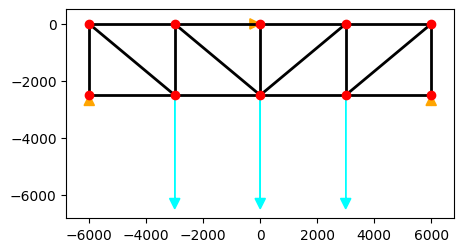

In [10]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [11]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  117.34790225767416  [kg]


The `solve` helper function is defined to compute the design 
responses (`drs`). Static response of the structure is computed. 

The design responses are the mass of the structure and the work of the applied forces.

In [12]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    W = dot(m["U"], m["F"])
    drs = (
        RHO * model.volume(m),
        W
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [13]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_work = drs[1]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Work: ", initial_work, '[N*mm]')



Initial structure
-----------------
Initial Design Variables:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Mass:  117.34790225767416  [kg]
Work:  96493.23473636375 [N*mm]


At this point we embark on the optimization. The objective 
function and the constraints need to be defined. 

Objective function is the normalized work of the applied loads.

In [14]:
def objective(dvs):
    drs = solve(dvs)
    return drs[1] / initial_work

The constraint on the mass of the structure expresses that we want the current mass of the structure to be less than or equal to the initial mass.

In [15]:
def constrain_mass(dvs):
    drs = solve(dvs)
    return (1 - drs[0] / initial_mass)

cons = [
    {"type": "ineq", "fun": constrain_mass},
]


Define lower and upper bounds for the design variables: locations of the joints may be varied at most by the full `SHIFT`. Hence the bounds are -1/+1.


In [16]:
bounds = [(-1.0, +1.0) for _ in range(10)]

Invoke the optimization function. 


In [17]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5303831572515542
            Iterations: 17
            Function evaluations: 188
            Gradient evaluations: 17


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [18]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The largest deflection is equal to the maximum allowed, and that constraint is then the only active constraint.

In [19]:
drs = solve(dvs)
opt_mass = drs[0]
opt_work = drs[1]
print("\nOptimized structure")
print("-----------------")
print("Optimized Design Variables: ", dvs)
print("Mass: ", 1000 * opt_mass, ' [kg]')
print("Optimized work: ", opt_work, ' [N*mm]')


Optimized structure
-----------------
Optimized Design Variables:  [ 3.47937512e-01 -7.95570745e-01 -1.65422633e-01  4.87756007e-01
 -9.74295135e-07  8.21381386e-01  1.65421100e-01  4.87756329e-01
 -3.47938184e-01 -7.95569888e-01]
Mass:  117.34790236820753  [kg]
Optimized work:  51178.38649288795  [N*mm]


The following visualization provides a graphical assessment of the optimized structure. Note how the bars in the upper chord join up with the verticals to form an arch.

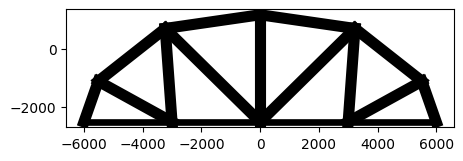

In [20]:
m = truss_model(dvs)
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m) 

The stiffness of the structure increased almost with a factor of 2 (otherwise, we could say the compliance halved).

## Conclusions

The optimization results in an arch, which efficiently uses the material of the bars: using the same amount of material, structure became almost twice as stiff. 